# Linear SVM Intent Classification

## Objective
This notebook trains a Linear Support Vector Machine (Linear SVM) for customer intent classification.

The preprocessing pipeline remains identical to the Logistic Regression notebook to ensure a fair comparison.

Models Compared:
- Logistic Regression
- Linear SVM

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [39]:
import pandas as pd 
import numpy as np 
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as pyplot
import seaborn as sns


In [5]:
df = pd.read_csv(
    "../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
)

df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
df.shape

(26872, 5)

In [26]:
print("Dataset Shape :", df.shape)
print("Columns :", df.columns.tolist())

Dataset Shape : (26872, 5)
Columns : ['flags', 'instruction', 'category', 'intent', 'response']


In [27]:
x =df["instruction"]
y=df["intent"]

In [28]:
print(x.iloc[0])
print(y.iloc[0])

question about cancelling order {{Order Number}}
cancel_order


In [29]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print("Number of Classes:", len(label_encoder.classes_))

Number of Classes: 27


In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.20,stratify = y)

In [31]:
x_train.shape


(21497,)

In [32]:
x_test.shape

(5375,)

In [33]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

x_train_tfidf = vectorizer.fit_transform(x_train)

x_test_tfidf = vectorizer.transform(x_test)

print("Training Matrix :", x_train_tfidf.shape)

print("Testing Matrix :", x_test_tfidf.shape)

print("Vocabulary Size :", len(vectorizer.get_feature_names_out()))

Training Matrix : (21497, 2443)
Testing Matrix : (5375, 2443)
Vocabulary Size : 2443


In [34]:
svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

In [35]:
svm_model.fit(
    x_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are su

In [36]:
y_pred_svm = svm_model.predict(
    x_test_tfidf
)

In [37]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.9808


In [38]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

            cancel_order       1.00      0.98      0.99       200
            change_order       0.95      0.98      0.97       199
 change_shipping_address       0.99      0.99      0.99       195
  check_cancellation_fee       1.00      0.99      1.00       190
           check_invoice       0.84      0.85      0.85       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       0.99      0.98      0.99       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.99      0.99      0.99       200
          create_account       0.96      0.99      0.98       199
          delete_account       0.99      1.00      1.00       199
        delivery_options       0.99      1.00      1.00       199
         delivery_period       1.00      0.99      1.00       200
         

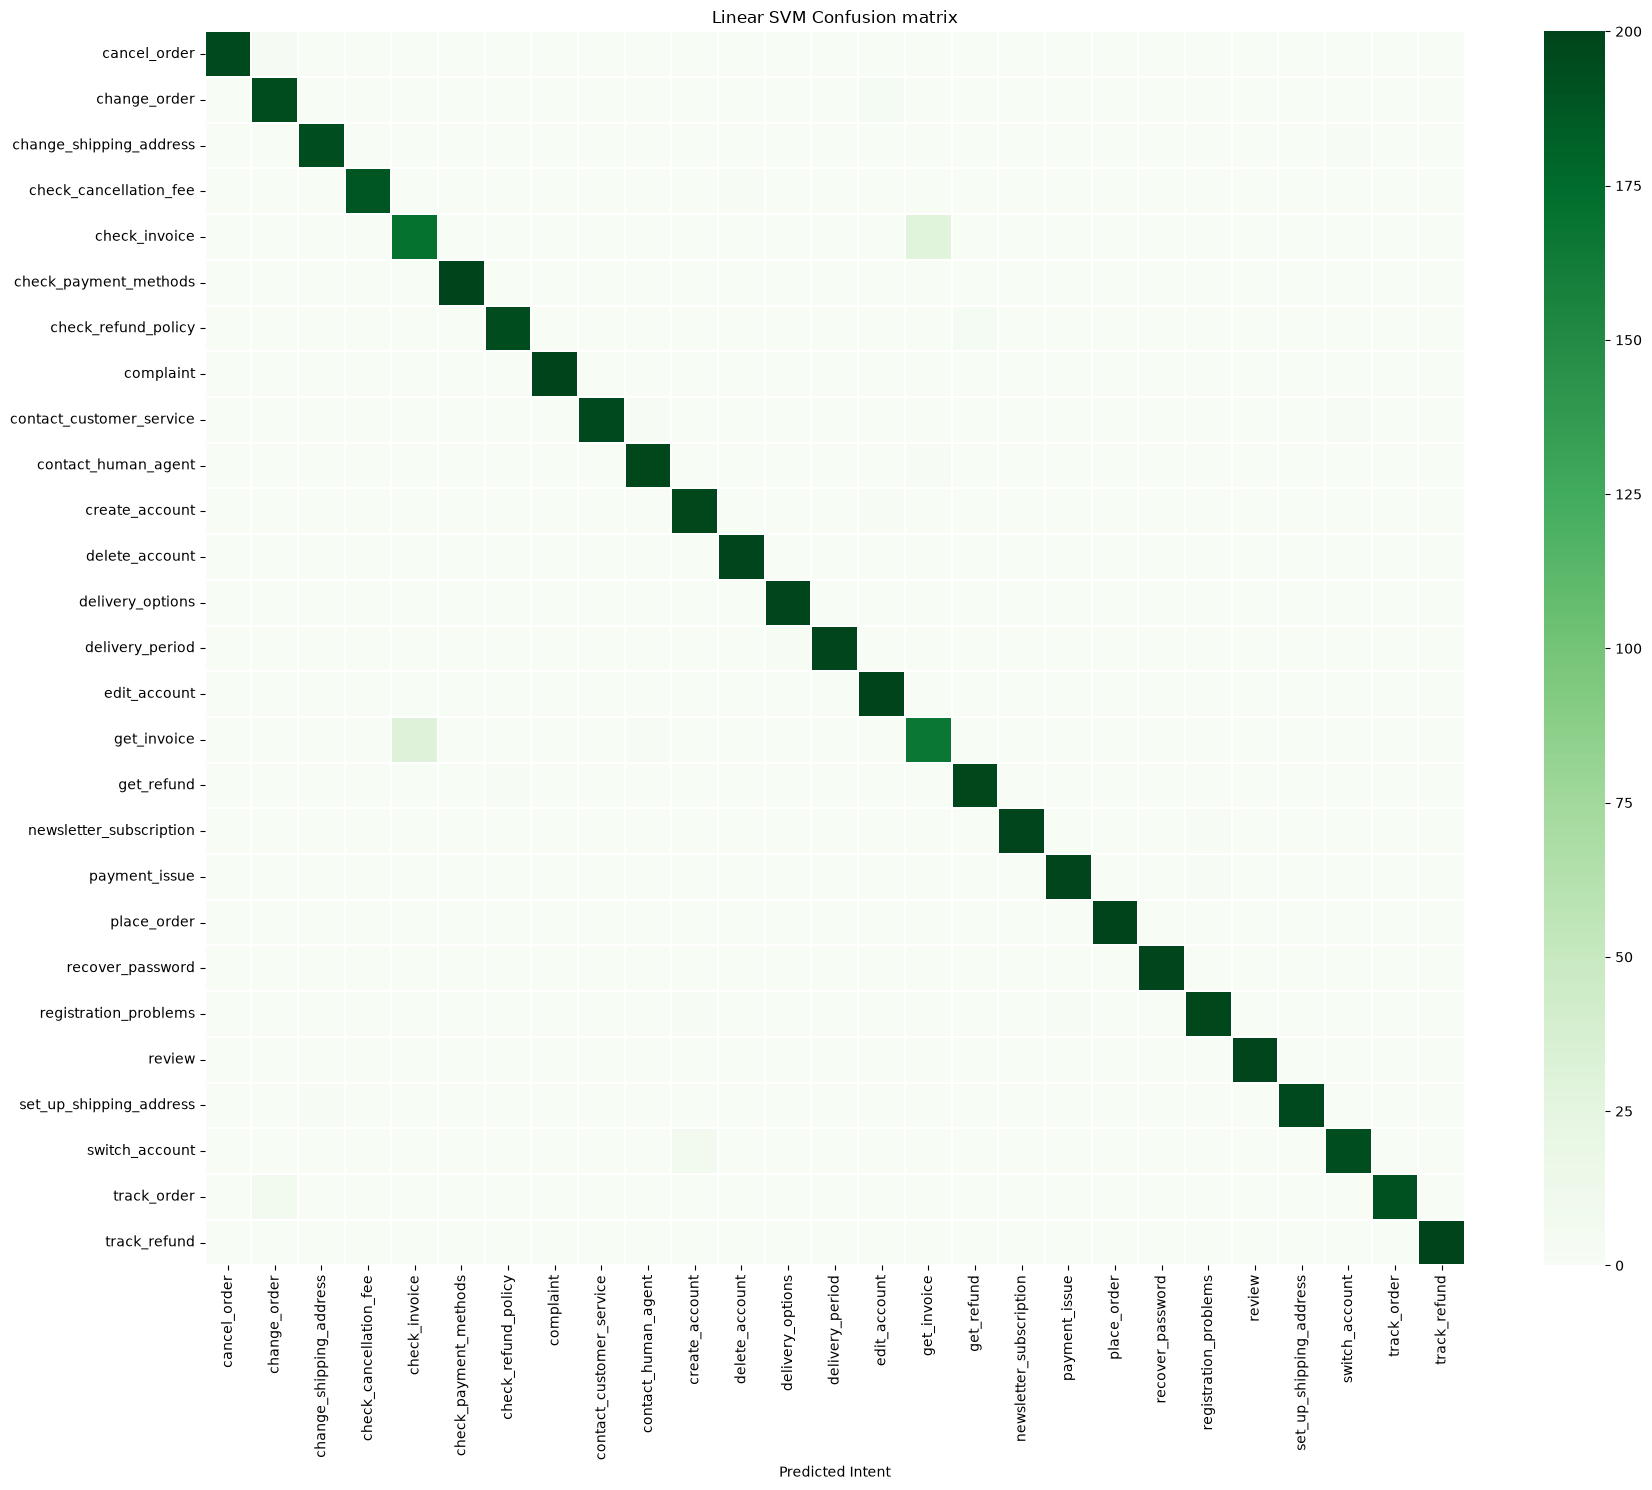

In [40]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)
plt.figure(figsize =(18,15))
sns.heatmap(
    cm_svm,
    cmap ="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.2
    
)
plt.title("Linear SVM Confusion matrix")
plt.xlabel("Predicted Intent")

plt.tight_layout()

plt.savefig(
    "../reports/figures/svm_confusion_matrix.png",
    dpi = 300,
    bbox_inches = "tight"
)
plt.show()

In [43]:
joblib.dump(
    svm_model ,
    "../backend/app/ai/svm_intent_classifier.pkl"
)

['../backend/app/ai/svm_intent_classifier.pkl']

In [45]:
svm_report = classification_report(
    y_test,
    y_pred_svm,
    target_names=label_encoder.classes_,
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report).transpose()

svm_report_df.to_csv(
    "../reports/metrics/svm_classification_report.csv"
)